In [2]:
!pip install ipykernel
!pip install skforecast
!pip install skforecast[full]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.2 MB/s eta 0:00:00


In [33]:
import sys

!{sys.executable} -m pip install --upgrade --user xgboost lightgbm catboost skforecast



  Using cached skforecast-0.22.0-py3-none-any.whl.metadata (20 kB)
Using cached skforecast-0.22.0-py3-none-any.whl (467 kB)


In [34]:
import numpy as np
import pandas as pd

from numpy import array
#from keras.models import Sequential
#from keras.layers import Dense
from numpy import asarray
from pandas import DataFrame
from pandas import concat

# Gráficos
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib import pyplot


In [35]:
import sys
import os

!pip install --target=$HOME/.local/lib/python3.10/site-packages catboost xgboost lightgbm skforecast

path_to_add = os.path.expanduser("~/.local/lib/python3.10/site-packages")
if path_to_add not in sys.path:
    sys.path.insert(0, path_to_add)

try:
    from catboost import CatBoostRegressor
    from xgboost import XGBRegressor
    from skforecast.ForecasterAutoreg import ForecasterAutoreg
    print("¡Éxito! Las librerías ya son visibles.")
except Exception as e:
    print(f"Sigue fallando. Error: {e}")

  Using cached catboost-1.2.10-cp312-cp312-manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
  Using cached skforecast-0.22.0-py3-none-any.whl.metadata (20 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached nvidia_nccl_cu12-2.30.4-py3-none-manylinux_2_18_x86_6

¡Éxito! Las librerías ya son visibles.


In [1]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline


In [2]:
##Regressor:

import sys

# 1. Desinstalar versiones previas que puedan estar causando ruido
!pip uninstall -y skforecast

# 2. Instalar una versión estable
!pip install skforecast==0.13.0

# 3. Forzar a Python a recargar el sistema de paquetes
import importlib
import site
importlib.reload(site)

print("Instalación terminada. Por favor, REINICIA EL ENTORNO (Runtime) y no corras el pip de nuevo.")

Found existing installation: skforecast 0.22.0
Uninstalling skforecast-0.22.0:
  Successfully uninstalled skforecast-0.22.0
Instalación terminada. Por favor, REINICIA EL ENTORNO (Runtime) y no corras el pip de nuevo.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
# --- Carga e indexado temporal ---
df = pd.read_csv('cafe_seguro_master.csv', parse_dates=['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)
df = df.set_index('fecha')
df.index.freq = 'MS'

print('DATASET ')
print(f'Periodo: {df.index.min().date()} → {df.index.max().date()}')
print(f'Shape:   {df.shape}')
print(f'\nPrimeras filas:')
print(df.head(3).round(2))

DATASET 
Periodo: 2002-01-01 → 2025-12-01
Shape:   (288, 9)

Primeras filas:
            year  month  prod_caldas_miles_sacos  prod_nacional_miles_sacos  \
fecha                                                                         
2002-01-01  2002      1                    84.60                      824.0   
2002-02-01  2002      2                    82.96                      808.0   
2002-03-01  2002      3                    79.88                      778.0   

            precip_mm  ndvi_mean  ndvi_median  ndvi_p90  precio_interno_cop  
fecha                                                                        
2002-01-01     118.09       0.80         0.82      0.89            276480.0  
2002-02-01     135.23       0.75         0.78      0.87            270960.0  
2002-03-01     234.07       0.68         0.73      0.85            296859.0  


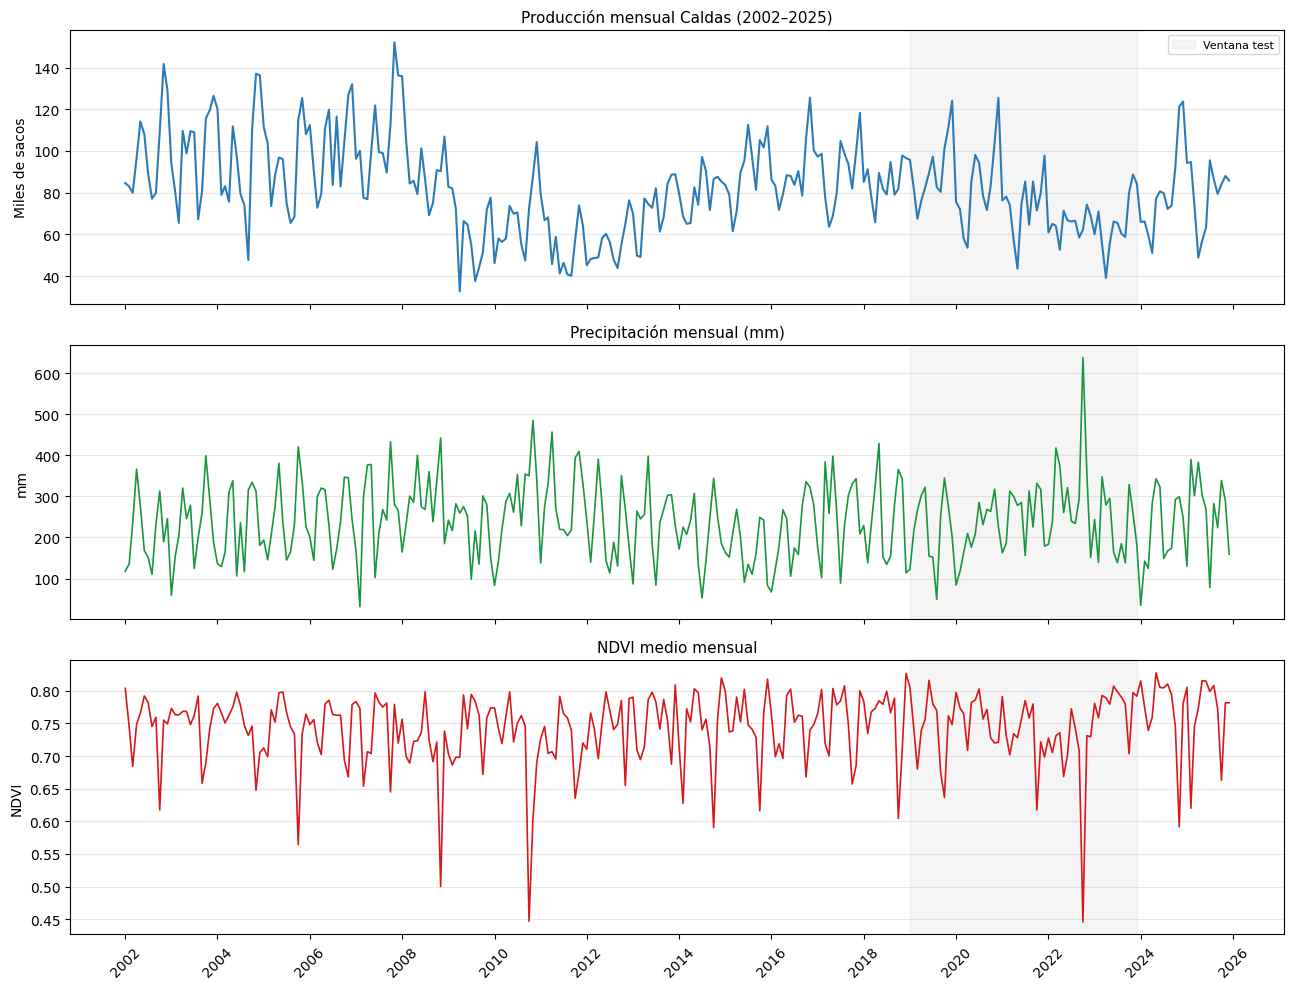

Gráfica guardada: sA_serie_temporal.png


In [5]:
# --- Visualización de la serie objetivo ---
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Panel 1 — Producción Caldas
axes[0].plot(df.index, df['prod_caldas_miles_sacos'],
             color='#2c7bb6', lw=1.5)
axes[0].set_ylabel('Miles de sacos')
axes[0].set_title('Producción mensual Caldas (2002–2025)', fontsize=11)
axes[0].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray', label='Ventana test')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Panel 2 — Precipitación
axes[1].plot(df.index, df['precip_mm'],
             color='#1a9641', lw=1.2)
axes[1].set_ylabel('mm')
axes[1].set_title('Precipitación mensual (mm)', fontsize=11)
axes[1].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray')
axes[1].grid(axis='y', alpha=0.3)

# Panel 3 — NDVI mean
axes[2].plot(df.index, df['ndvi_mean'],
             color='#d7191c', lw=1.2)
axes[2].set_ylabel('NDVI')
axes[2].set_title('NDVI medio mensual', fontsize=11)
axes[2].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray')
axes[2].grid(axis='y', alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sA_serie_temporal.png', dpi=150)
plt.show()
print("Gráfica guardada: sA_serie_temporal.png")


In [6]:
# --- Estadística descriptiva por componente ---
print("\n PRODUCCIÓN CALDAS — ESTADÍSTICA POR AÑO ")
resumen_anual = (df['prod_caldas_miles_sacos']
                 .resample('YE')
                 .agg(['sum','mean','min','max'])
                 .round(1))
resumen_anual.index = resumen_anual.index.year
resumen_anual.columns = ['total_anual','media_mensual','min_mensual','max_mensual']
print(resumen_anual.to_string())


 PRODUCCIÓN CALDAS — ESTADÍSTICA POR AÑO 
       total_anual  media_mensual  min_mensual  max_mensual
fecha                                                      
2002        1192.4           99.4         77.1        141.7
2003        1175.7           98.0         65.5        126.4
2004        1152.0           96.0         47.7        137.0
2005        1126.8           93.9         65.5        125.4
2006        1232.0          102.7         72.7        132.0
2007        1261.0          105.1         76.9        152.1
2008        1110.2           92.5         69.2        135.8
2009         738.2           61.5         32.6         82.8
2010         799.4           66.6         46.1        104.3
2011         682.7           56.9         40.1         79.4
2012         653.6           54.5         43.8         76.3
2013         866.8           72.2         49.1         88.8
2014         953.9           79.5         65.1         97.1
2015        1090.2           90.8         61.5        112

**Preprocesamiento**

In [7]:
# formato fecha
df.index = pd.to_datetime(df.index)

# Frecuencia mensual
df = df.asfreq('MS')

# Verificar valores nulos
if df.isnull().values.any():
    print("Atención: Se detectaron meses faltantes o valores nulos.")
    df = df.interpolate(method='linear')
# Conteo de nulos
print("Conteo de valores nulos por variable:")
print(df.isnull().sum())

# Porcentaje de nulos
print("\nPorcentaje de nulos:")
print((df.isnull().sum() / len(df)) * 100)

Conteo de valores nulos por variable:
year                         0
month                        0
prod_caldas_miles_sacos      0
prod_nacional_miles_sacos    0
precip_mm                    0
ndvi_mean                    0
ndvi_median                  0
ndvi_p90                     0
precio_interno_cop           0
dtype: int64

Porcentaje de nulos:
year                         0.0
month                        0.0
prod_caldas_miles_sacos      0.0
prod_nacional_miles_sacos    0.0
precip_mm                    0.0
ndvi_mean                    0.0
ndvi_median                  0.0
ndvi_p90                     0.0
precio_interno_cop           0.0
dtype: float64


In [8]:
# Crear una columna de fecha combinando year y month
df['fecha'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

# Establecer la fecha como índice y ordenar
df = df.set_index('fecha').sort_index()

# Establecer frecuencia mensual
df = df.asfreq('MS')

print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Rango temporal: 2002-01-01 00:00:00 a 2025-12-01 00:00:00


In [9]:

# Creamos una copia
df_feat = df.copy()

# Lag precopitacion 10 por ETL
df_feat['precip_lag10'] = df_feat['precip_mm'].shift(10)

# Para NDVI lag 5
df_feat['ndvi_lag5'] = df_feat['ndvi_mean'].shift(5)

# Ingeniería de variables cíclicas (Estacionalidad)s
df_feat['mes_sin'] = np.sin(2 * np.pi * df_feat.index.month / 12)
df_feat['mes_cos'] = np.cos(2 * np.pi * df_feat.index.month / 12)

# Tendencia
df_feat['tendencia'] = np.arange(len(df_feat))

# Limpieza de NaNs
df_feat = df_feat.dropna()

print(f"Registros y columnas: {df_feat.shape[0]} registros y {df_feat.shape[1]} columnas.")

Registros y columnas: 278 registros y 14 columnas.


**Definición de variables**

In [10]:
# Lista de variables
columnas_exog = [
    'precip_mm', 'precip_lag10',
    'ndvi_mean', 'ndvi_lag5',
    'mes_sin', 'mes_cos',
    'tendencia', 'precio_interno_cop'
]

**Partción Train/test**

In [11]:
# Train
datos_train = df_feat.loc[:'2018-12-01']
X_train = datos_train[columnas_exog]
y_train = datos_train['prod_caldas_miles_sacos']

# Test
datos_test = df_feat.loc['2019-01-01':'2023-12-31']
X_test = datos_test[columnas_exog]
y_test = datos_test['prod_caldas_miles_sacos']

# Demo
datos_demo = df_feat.loc['2024-01-01':]
X_demo = datos_demo[columnas_exog]
y_demo = datos_demo['prod_caldas_miles_sacos']


print(f"Corte realizado:")
print(f" - Entrenamiento: {len(datos_train)} meses")
print(f" - Prueba (Test): {len(datos_test)} meses")

Corte realizado:
 - Entrenamiento: 194 meses
 - Prueba (Test): 60 meses


**Visualización Train/Test**

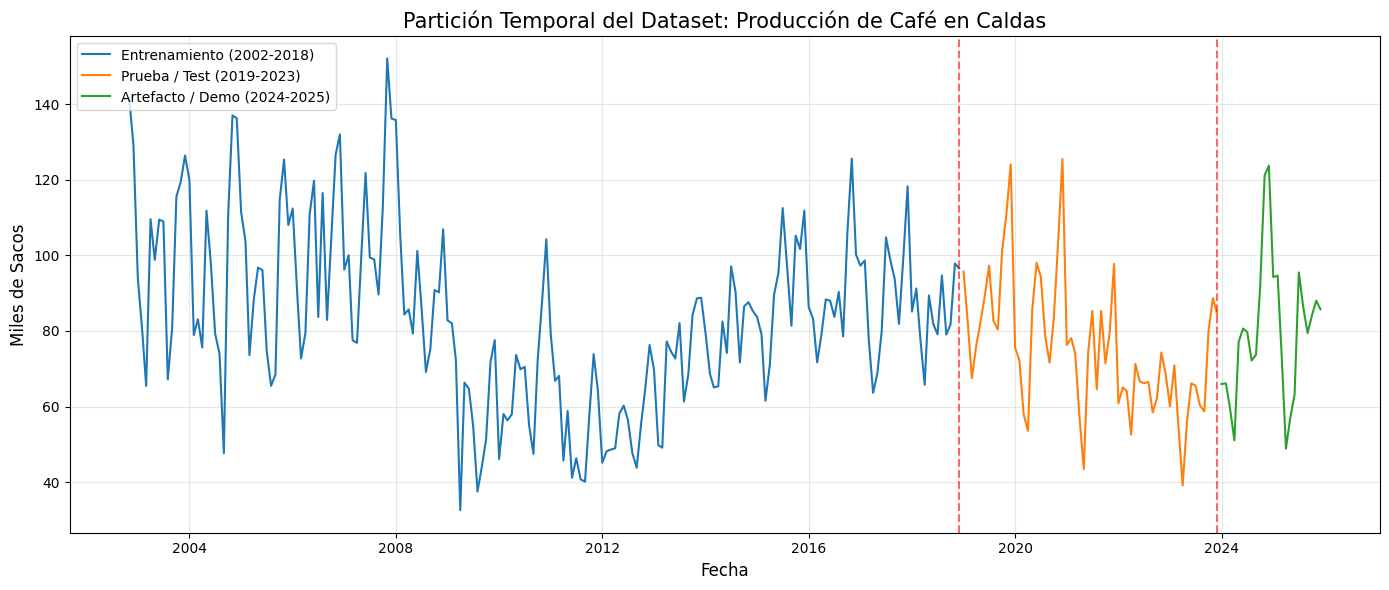

In [12]:

plt.figure(figsize=(14, 6))


plt.plot(datos_train.index, datos_train['prod_caldas_miles_sacos'], label='Entrenamiento (2002-2018)', color='#1f77b4')
plt.plot(datos_test.index, datos_test['prod_caldas_miles_sacos'], label='Prueba / Test (2019-2023)', color='#ff7f0e')
plt.plot(datos_demo.index, datos_demo['prod_caldas_miles_sacos'], label='Artefacto / Demo (2024-2025)', color='#2ca02c')

plt.axvline(datos_train.index.max(), color='red', linestyle='--', alpha=0.6)
plt.axvline(datos_test.index.max(), color='red', linestyle='--', alpha=0.6)

plt.title('Partición Temporal del Dataset: Producción de Café en Caldas', fontsize=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Miles de Sacos', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

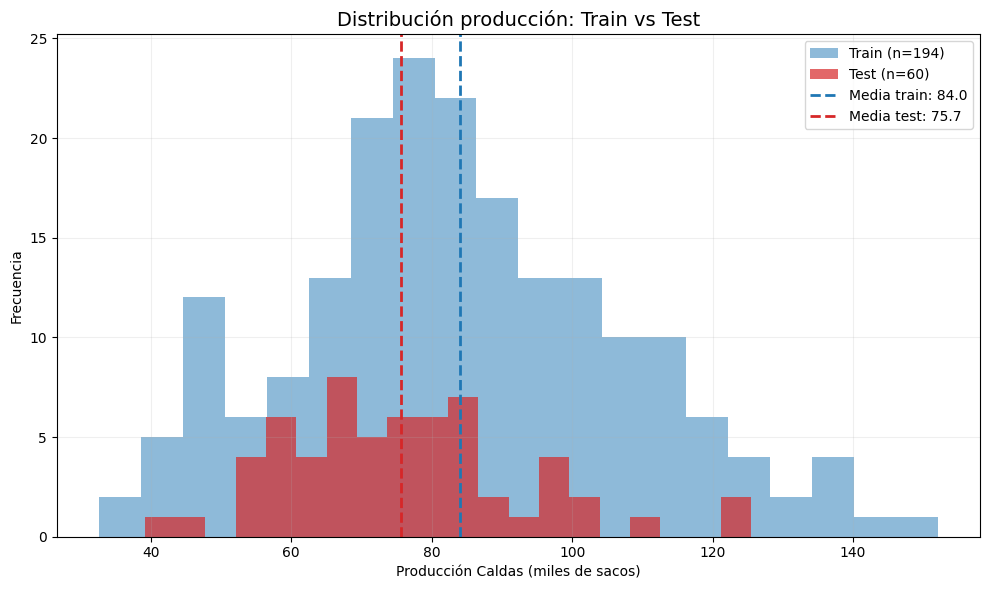


 ESTADÍSTICA COMPARATIVA TRAIN vs TEST 
      Train (2002-2018) Test (2019-2023)
count            194.00            60.00
mean              84.01            75.65
std               23.39            17.50
min               32.60            39.14
25%               68.69            64.44
50%               82.06            74.16
75%               98.77            84.62
max              152.11           125.50


In [14]:

stats_train = datos_train['prod_caldas_miles_sacos'].describe()
stats_test = datos_test['prod_caldas_miles_sacos'].describe()
stats_df = pd.DataFrame({'Train (2002-2018)': stats_train, 'Test (2019-2023)': stats_test})


plt.figure(figsize=(10, 6))

plt.hist(datos_train['prod_caldas_miles_sacos'], bins=20, alpha=0.5, label=f'Train (n={len(datos_train)})', color='#1f77b4')
plt.hist(datos_test['prod_caldas_miles_sacos'], bins=20, alpha=0.7, label=f'Test (n={len(datos_test)})', color='#d62728')

plt.axvline(stats_train['mean'], color='#1f77b4', linestyle='--', linewidth=2, label=f'Media train: {stats_train["mean"]:.1f}')
plt.axvline(stats_test['mean'], color='#d62728', linestyle='--', linewidth=2, label=f'Media test: {stats_test["mean"]:.1f}')

plt.title('Distribución producción: Train vs Test', fontsize=14)
plt.xlabel('Producción Caldas (miles de sacos)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("\n ESTADÍSTICA COMPARATIVA TRAIN vs TEST ")
print(stats_df.to_string(formatters={'Train (2002-2018)': '{:,.2f}'.format, 'Test (2019-2023)': '{:,.2f}'.format}))

**Configuración de los modelos**

In [14]:

import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from skforecast.ForecasterAutoreg import ForecasterAutoreg


def calcular_metricas(y_true, y_pred, modelo, dataset):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

    r2 = r2_score(y_true, y_pred)

    return {
        'modelo': modelo,
        'dataset': dataset,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    }


ESPECIFICACIONES_XGB = {

    'M1_XGB_simple': {
        'n_estimators': 300,
        'max_depth': 3,
        'learning_rate': 0.05,
        'random_state': 42
    },

    'M2_XGB_intermedio': {
        'n_estimators': 500,
        'max_depth': 4,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'random_state': 42
    },

    'M3_XGB_regularizado': {
        'n_estimators': 600,
        'max_depth': 3,
        'learning_rate': 0.03,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 1,
        'reg_lambda': 1,
        'random_state': 42
    },

    'M4_XGB_balanceado': {
        'n_estimators': 700,
        'max_depth': 3,
        'learning_rate': 0.02,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.5,
        'reg_lambda': 2,
        'random_state': 42
    },
    'M5_XGB_regularizado': {
        'n_estimators': 400,
        'max_depth': 2,
        'learning_rate': 0.02,
        'subsample': 0.7,
        'colsample_bytree': 0.7,
        'reg_alpha': 2,
        'reg_lambda': 3,
        'min_child_weight': 5,
        'gamma': 1,
        'random_state': 42
    },

}


metricas_resumen = []
resultados_xgb = {}

for nombre, params in ESPECIFICACIONES_XGB.items():

    print(f"Entrenando {nombre}...")

    forecaster_temp = ForecasterAutoreg(
        regressor = XGBRegressor(**params),
        lags      = [1, 2, 3, 6, 12]
    )

    forecaster_temp.fit(
        y    = datos_train['prod_caldas_miles_sacos'],
        exog = datos_train[columnas_exog]
    )

    pred_test = forecaster_temp.predict(
        steps = len(datos_test),
        exog  = datos_test[columnas_exog]
    )

    m_test = calcular_metricas(
        datos_test['prod_caldas_miles_sacos'],
        pred_test,
        nombre,
        'test'
    )

    metricas_resumen.append(m_test)
    resultados_xgb[nombre] = forecaster_temp

# RESULTADOS

df_metricas = pd.DataFrame(metricas_resumen)

# Ordenar por mejor modelo
df_metricas = df_metricas.sort_values(by='RMSE')

print("\nResultados:")
display(df_metricas)


Entrenando M1_XGB_simple...
Entrenando M2_XGB_intermedio...
Entrenando M3_XGB_regularizado...
Entrenando M4_XGB_balanceado...
Entrenando M5_XGB_regularizado...

Resultados:


,modelo,dataset,RMSE,MAE,MAPE,R2
4,M5_XGB_regularizado,test,12.988245,10.209739,15.053081,0.439797
3,M4_XGB_balanceado,test,14.825731,12.191942,18.312831,0.270078
1,M2_XGB_intermedio,test,15.150441,12.323939,18.289608,0.237754
0,M1_XGB_simple,test,15.621397,12.664626,19.191252,0.189628
2,M3_XGB_regularizado,test,15.915780,13.414273,20.084882,0.158798


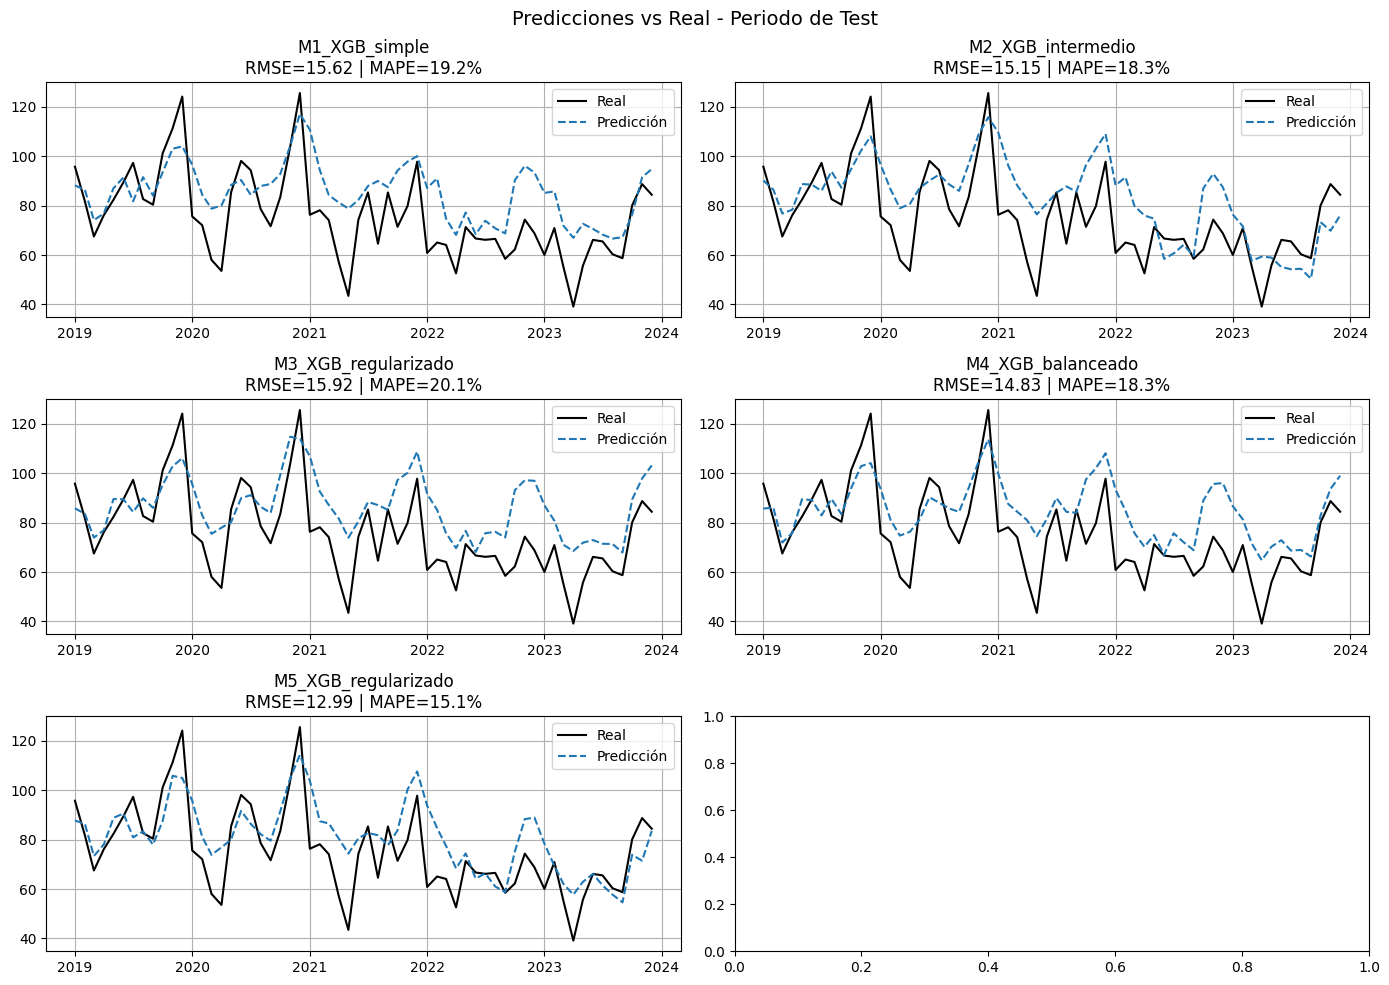

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(resultados_xgb.items()):

    # Predicción en test
    pred_test = modelo.predict(
        steps=len(datos_test),
        exog=datos_test[columnas_exog]
    )

    # Métricas (para poner en el título)
    rmse = np.sqrt(mean_squared_error(
        datos_test['prod_caldas_miles_sacos'], pred_test))

    mape = np.mean(
        np.abs((datos_test['prod_caldas_miles_sacos'] - pred_test) /
               np.where(datos_test['prod_caldas_miles_sacos'] == 0, 1,
                        datos_test['prod_caldas_miles_sacos']))
    ) * 100

    # Gráfica
    axes[i].plot(
        datos_test.index,
        datos_test['prod_caldas_miles_sacos'],
        label='Real',
        color='black'
    )

    axes[i].plot(
        datos_test.index,
        pred_test,
        label='Predicción',
        linestyle='--'
    )

    axes[i].set_title(f"{nombre}\nRMSE={rmse:.2f} | MAPE={mape:.1f}%")
    axes[i].legend()
    axes[i].grid()

# Ajustar layout
plt.suptitle("Predicciones vs Real - Periodo de Test", fontsize=14)
plt.tight_layout()
plt.show()


Mejor modelo: M5_XGB_regularizado


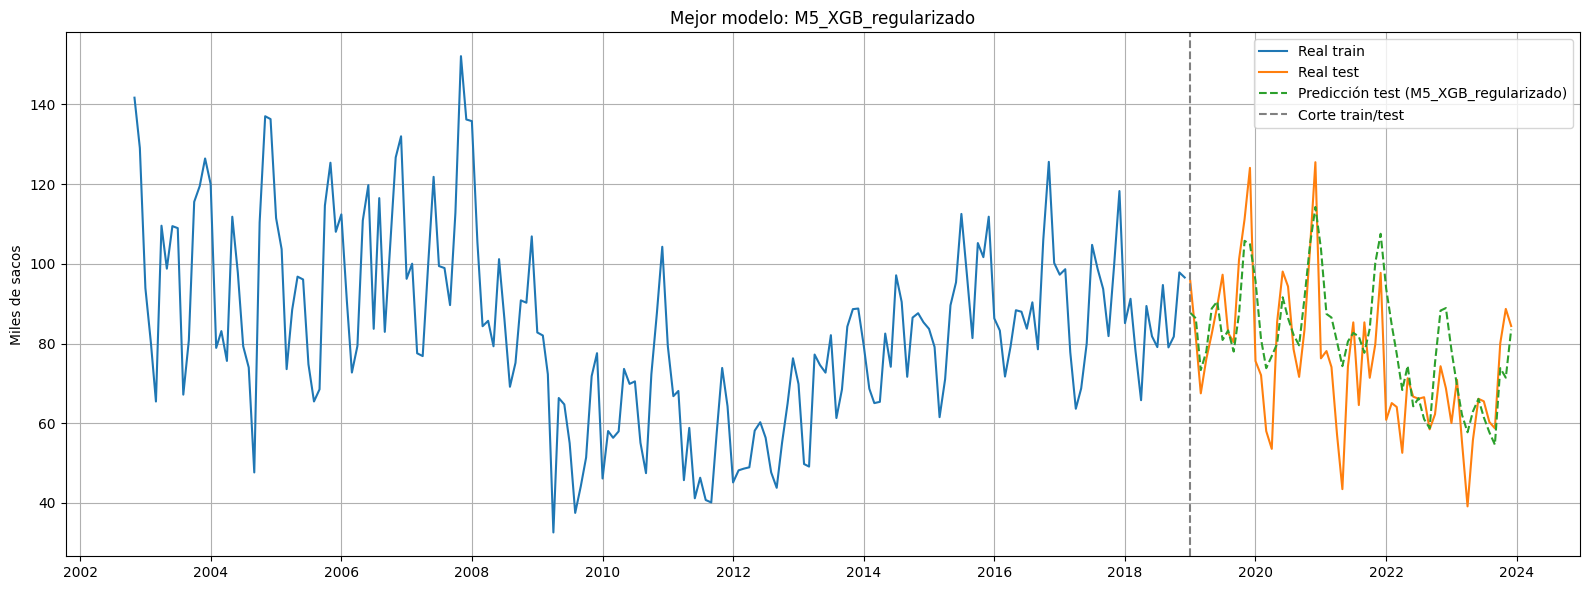

Gráfica guardada como: mejor_modelo.png


<Figure size 640x480 with 0 Axes>

In [24]:

import matplotlib.dates as mdates



from skforecast.ForecasterAutoreg import ForecasterAutoreg



# Mejor modelo
mejor = df_metricas.iloc[0]['modelo']
print("Mejor modelo:", mejor)

mejor_modelo = resultados_xgb[mejor]

#Predicción

pred_test = mejor_modelo.predict(
    steps=len(datos_test),
    exog=datos_test[columnas_exog]
)

#Grafica
fig, ax = plt.subplots(figsize=(16, 6))


ax.plot(datos_train.index,
        datos_train['prod_caldas_miles_sacos'],
        label='Real train')

ax.plot(datos_test.index,
        datos_test['prod_caldas_miles_sacos'],
        label='Real test')

ax.plot(datos_test.index,
        pred_test,
        linestyle='--',
        label=f'Predicción test ({mejor})')


ax.axvline(datos_test.index[0],
           linestyle='--',
           color='gray',
           label='Corte train/test')


ax.set_title(f'Mejor modelo: {mejor}')
ax.set_ylabel('Miles de sacos')
ax.legend()
ax.grid()

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.show()



plt.savefig("mejor_modelo.png", dpi=300, bbox_inches='tight')
print("Gráfica guardada como: mejor_modelo.png")


**Analisis de Residuos**

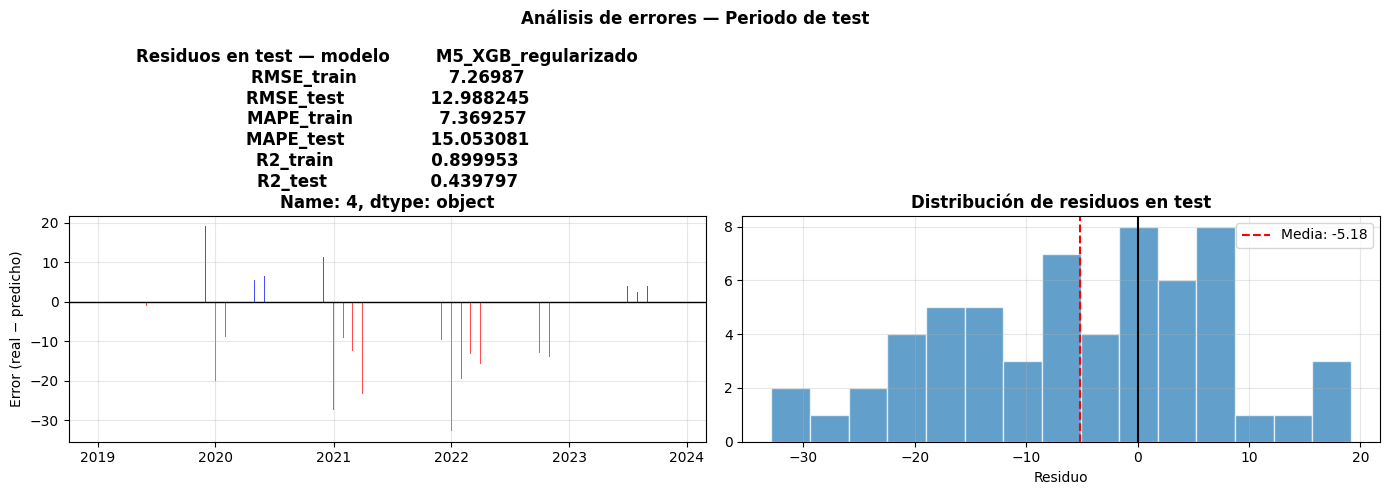

Gráfica guardada: residuos_test.png


<Figure size 640x480 with 0 Axes>

In [16]:


# Residuos
residuos = datos_test['prod_caldas_miles_sacos'].values - pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuos en el tiempo

axes[0].bar(
    datos_test.index,
    residuos,
    color=['red' if r < 0 else 'blue' for r in residuos],
    alpha=0.7
)

axes[0].axhline(0, color='black', lw=1)
axes[0].set_ylabel('Error (real − predicho)')
axes[0].set_title(f'Residuos en test — {mejor}', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Histograma de residuos

axes[1].hist(residuos, bins=15, alpha=0.7, edgecolor='white')

axes[1].axvline(0, color='black', lw=1.5)
axes[1].axvline(
    np.mean(residuos),
    color='red',
    lw=1.5,
    linestyle='--',
    label=f'Media: {np.mean(residuos):.2f}'
)

axes[1].set_xlabel('Residuo')
axes[1].set_title('Distribución de residuos en test', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Análisis de errores — Periodo de test',
             fontsize=12,
             fontweight='bold')

plt.tight_layout()
plt.show()

plt.savefig('residuos_test.png', dpi=300, bbox_inches='tight')
print('Gráfica guardada: residuos_test.png')


**QQ-plot**

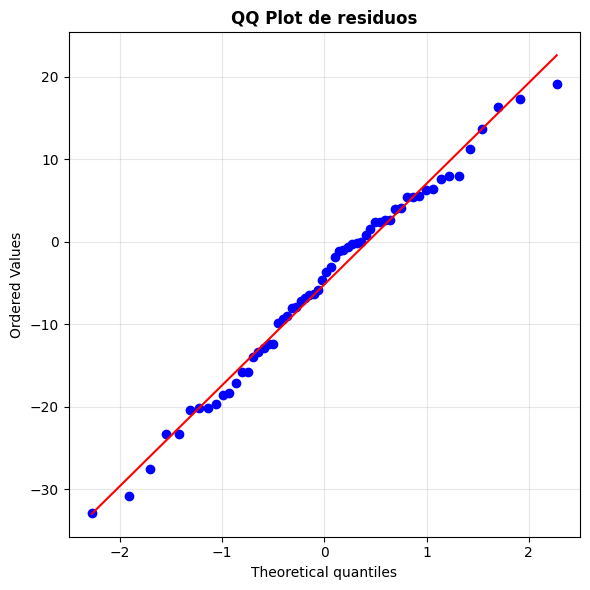

In [17]:
import scipy.stats as stats


# Residuos
residuos = datos_test['prod_caldas_miles_sacos'].values - pred_test

# QQ Plot
plt.figure(figsize=(6, 6))

stats.probplot(residuos, dist="norm", plot=plt)

plt.title('QQ Plot de residuos', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Importancia de variables**

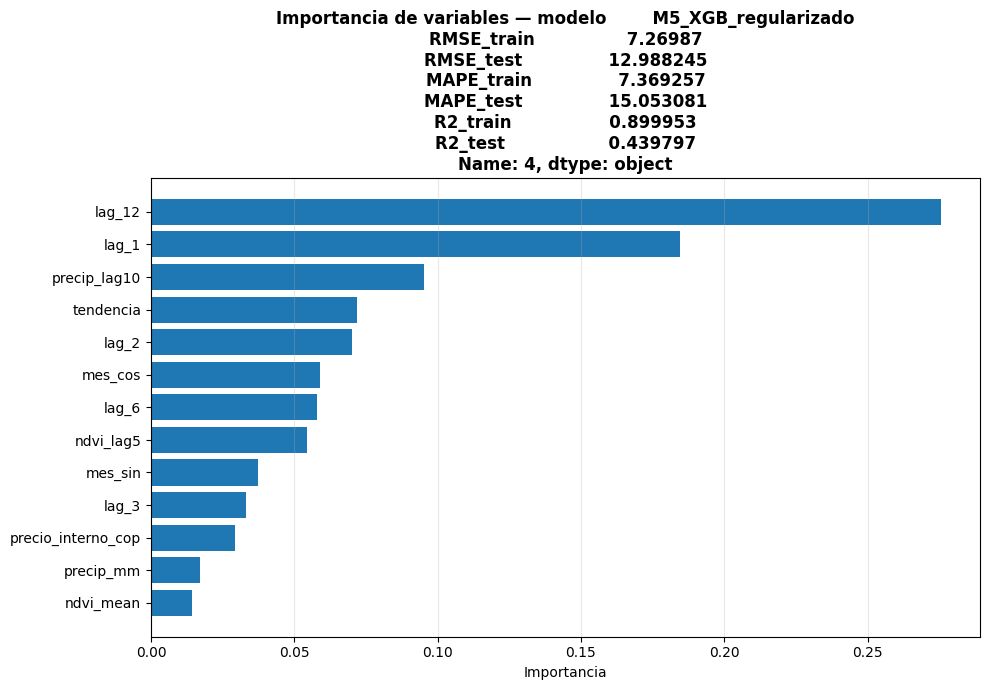


=== RANKING DE IMPORTANCIA ===
lag_12                        : 0.2755 ███████████████████████████
lag_1                         : 0.1846 ██████████████████
precip_lag10                  : 0.0953 █████████
tendencia                     : 0.0718 ███████
lag_2                         : 0.0701 ███████
mes_cos                       : 0.0591 █████
lag_6                         : 0.0580 █████
ndvi_lag5                     : 0.0544 █████
mes_sin                       : 0.0373 ███
lag_3                         : 0.0331 ███
precio_interno_cop            : 0.0292 ██
precip_mm                     : 0.0171 █
ndvi_mean                     : 0.0145 █


In [18]:


# XGBoost
modelo_xgb = mejor_modelo.regressor


feature_names = mejor_modelo.create_train_X_y(
    y=datos_train['prod_caldas_miles_sacos'],
    exog=datos_train[columnas_exog]
)[0].columns

# Importancias
importancias = pd.Series(
    modelo_xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)


# GRÁFICA


fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(importancias.index[::-1],
        importancias.values[::-1])

ax.set_xlabel('Importancia')
ax.set_title(f'Importancia de variables — {mejor}',
             fontweight='bold')

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


print('\n=== RANKING DE IMPORTANCIA ===')
for f, v in importancias.items():
    barra = '█' * int(v * 100)
    print(f'{f:<30}: {v:.4f} {barra}')


In [15]:


# =========================
# TABLA DE MÉTRICAS (TRAIN + TEST)
# =========================

metricas_resumen = []

for nombre, params in ESPECIFICACIONES_XGB.items():

    print(f"Entrenando {nombre}...")

    forecaster_temp = ForecasterAutoreg(
        regressor = XGBRegressor(**params),
        lags=[1, 2, 3, 6, 12]
    )

    forecaster_temp.fit(
        y=datos_train['prod_caldas_miles_sacos'],
        exog=datos_train[columnas_exog]
    )

    # ===== TRAIN =====
    X_train_f, y_train_f = forecaster_temp.create_train_X_y(
        y=datos_train['prod_caldas_miles_sacos'],
        exog=datos_train[columnas_exog]
    )

    pred_train = forecaster_temp.regressor.predict(X_train_f)

    # ===== TEST =====
    pred_test = forecaster_temp.predict(
        steps=len(datos_test),
        exog=datos_test[columnas_exog]
    )

    # ===== MÉTRICAS =====
    rmse_train = np.sqrt(mean_squared_error(y_train_f, pred_train))
    rmse_test = np.sqrt(mean_squared_error(datos_test['prod_caldas_miles_sacos'], pred_test))

    mape_train = np.mean(np.abs((y_train_f - pred_train) / np.where(y_train_f == 0, 1, y_train_f))) * 100
    mape_test = np.mean(np.abs((datos_test['prod_caldas_miles_sacos'] - pred_test) / np.where(datos_test['prod_caldas_miles_sacos'] == 0, 1, datos_test['prod_caldas_miles_sacos']))) * 100

    r2_train = r2_score(y_train_f, pred_train)
    r2_test = r2_score(datos_test['prod_caldas_miles_sacos'], pred_test)

    metricas_resumen.append({
        'modelo': nombre,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'MAPE_train': mape_train,
        'MAPE_test': mape_test,
        'R2_train': r2_train,
        'R2_test': r2_test
    })

# =========================
# CREAR TABLA FINAL
# =========================

df_metricas = pd.DataFrame(metricas_resumen)
df_metricas = df_metricas.sort_values(by='RMSE_test')

print('\n' + '='*75)
print('RESUMEN FINAL — COMPARATIVA DE MODELOS XGBOOST')
print('='*75)

print(df_metricas.round(3).to_string(index=False))


mejor = df_metricas.iloc[0]

print('\n' + '='*75)
print(f" Mejor modelo en test (menor RMSE): {mejor['modelo']}")
print('='*75)

print(f"RMSE test : {mejor['RMSE_test']:.3f} miles de sacos")
print(f"MAPE test : {mejor['MAPE_test']:.2f}%")
print(f"R² test   : {mejor['R2_test']:.3f}")


print('\n=== TOP 3 VARIABLES MÁS IMPORTANTES ===')

# Limpiar nombre (MUY IMPORTANTE)
nombre_mejor = mejor['modelo'].strip()

# Obtener modelo correcto
mejor_modelo = resultados_xgb[nombre_mejor]

modelo_xgb = mejor_modelo.regressor

# Obtener variables
X_train_f, _ = mejor_modelo.create_train_X_y(
    y=datos_train['prod_caldas_miles_sacos'],
    exog=datos_train[columnas_exog]
)

feature_names = X_train_f.columns

# Importancias
importancias = pd.Series(
    modelo_xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Top 3
top3 = importancias.head(3)

for i, (f, v) in enumerate(top3.items(), 1):
    print(f"{i}. {f}: {v:.4f}")




Entrenando M1_XGB_simple...
Entrenando M2_XGB_intermedio...
Entrenando M3_XGB_regularizado...
Entrenando M4_XGB_balanceado...
Entrenando M5_XGB_regularizado...

RESUMEN FINAL — COMPARATIVA DE MODELOS XGBOOST
             modelo  RMSE_train  RMSE_test  MAPE_train  MAPE_test  R2_train  R2_test
M5_XGB_regularizado       7.270     12.988       7.369     15.053     0.900    0.440
  M4_XGB_balanceado       2.658     14.826       2.707     18.313     0.987    0.270
  M2_XGB_intermedio       0.153     15.150       0.154     18.290     1.000    0.238
      M1_XGB_simple       2.546     15.621       2.636     19.191     0.988    0.190
M3_XGB_regularizado       1.796     15.916       1.844     20.085     0.994    0.159

 Mejor modelo en test (menor RMSE): M5_XGB_regularizado
RMSE test : 12.988 miles de sacos
MAPE test : 15.05%
R² test   : 0.440

=== TOP 3 VARIABLES MÁS IMPORTANTES ===
1. lag_12: 0.2755
2. lag_1: 0.1846
3. precip_lag10: 0.0953
